# Deep dive into SimHash and the LSH index

In this notebook, we will talk about the theory and mechanics behind `SimHashIndexANN`, the approximate nearest neighbour (ANN) index used for whole-series similarity search in aeon. We will see how it hashes time series so that similar series tend to share the same "fingerprint", why this works (the famous $1 - \theta/\pi$ collision probability), and how aeon turns these fingerprints into a fast index.

For a general introduction to the similarity search module, see the [Time Series Similarity Search with aeon](similarity_search.ipynb) notebook. For the theory behind distance profiles (the exact, subsequence side of the module), see the [Deep dive in the distance profiles](distance_profiles.ipynb) notebook. For an experimental analysis of how to tune this index for accuracy versus query speed, see the [Analysis of the speedups](code_speed.ipynb) notebook.

## Why approximate search ?

The exact whole-series search (`NaiveSeriesSearch`) answers a query by computing the distance between the query and every series in the collection, then keeping the $k$ smallest. This is simple and exact, but it scans the whole collection for each query : with $n$ series of length $m$, a single query costs $O(n \times m)$ operations. On large collections, this becomes the bottleneck.

The idea behind Locality-Sensitive Hashing (LSH) is to avoid looking at most of the collection. We give each series a short *fingerprint* (a hash), built so that similar series are likely to get the same fingerprint, while dissimilar series are likely to get different ones. At fit time, we group the series by fingerprint into buckets. At query time, we only compute the fingerprint of the query and look into the matching bucket(s), comparing the query against the few series found there instead of the whole collection.

`SimHashIndexANN` implements this idea with a specific hashing scheme called SimHash, which we describe now.

## Hashing a series with a random projection

SimHash builds the fingerprint one *bit* at a time. To produce a single bit, we draw a random vector $w$ (the same length as the series) and look at the sign of the dot product between the series and $w$.

Let a series be flattened into a single vector $x = \{x_1, \ldots, x_d\}$ of length $d = \texttt{n\_channels} \times \texttt{n\_timepoints}$ (a multivariate series is simply read as one long vector). Given a random projection vector $w = \{w_1, \ldots, w_d\}$, the bit is :

$$ b(x) = \begin{cases} 1 & \text{if } \langle w, x \rangle \geq 0 \\ 0 & \text{otherwise} \end{cases} \qquad \text{where } \langle w, x \rangle = \sum_{j=1}^{d} w_j x_j $$

Geometrically, $w$ is the normal of a hyperplane passing through the origin. The hyperplane cuts the space in two half-spaces, and the bit simply records on which side of the hyperplane the series falls. The figure below illustrates this in 2D : each point is a "series", the dashed line is the hyperplane $\langle w, x \rangle = 0$, and the colour is the bit.

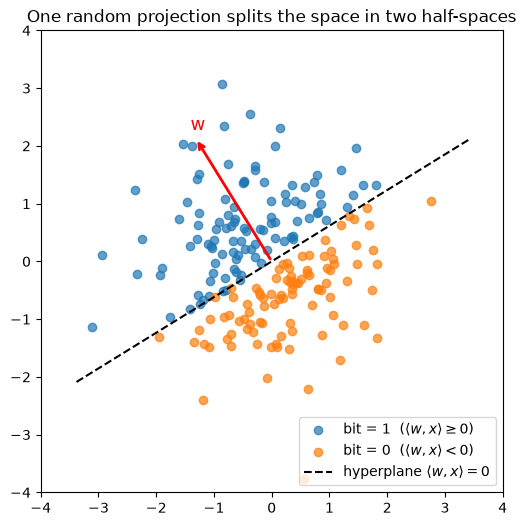

In [1]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

# 200 toy 2D "series", and one random projection vector w
points = rng.standard_normal((200, 2))
w = rng.standard_normal(2)

bit = (points @ w) >= 0  # the SimHash bit of each point

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    *points[bit].T,
    color="tab:blue",
    alpha=0.7,
    label=r"bit = 1  ($\langle w, x \rangle \geq 0$)",
)
ax.scatter(
    *points[~bit].T,
    color="tab:orange",
    alpha=0.7,
    label=r"bit = 0  ($\langle w, x \rangle < 0$)",
)

# the hyperplane is the line through the origin perpendicular to w
direction = np.array([-w[1], w[0]])
direction /= np.linalg.norm(direction)
line = np.outer([-4, 4], direction)
ax.plot(line[:, 0], line[:, 1], "k--", label=r"hyperplane $\langle w, x \rangle = 0$")

# draw w itself
w_unit = 2.5 * w / np.linalg.norm(w)
ax.annotate(
    "",
    xy=w_unit,
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
)
ax.text(*(w_unit * 1.07), "w", color="red", fontsize=13)

ax.set_aspect("equal")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("One random projection splits the space in two half-spaces")
ax.legend(loc="lower right")
plt.show()

## Why we normalize before hashing

The bit only depends on the sign of $\langle w, x \rangle$, which already gives SimHash one invariance for free : multiplying a series by any positive constant $\alpha > 0$ leaves every bit unchanged, since $\langle w, \alpha x \rangle = \alpha \langle w, x \rangle$ keeps the same sign. SimHash is therefore naturally blind to a *global* rescaling of a series : two series with the same shape but different overall scales already hash the same way, with no normalization needed.

What it is *not* blind to is a constant offset. Shifting a series vertically by $c$ replaces $x$ with $x + c\mathbf{1}$ (with $\mathbf{1}$ the all-ones vector), and

$$ \langle w, x + c\mathbf{1} \rangle = \langle w, x \rangle + c\,\langle w, \mathbf{1} \rangle , $$

which can flip the sign of the projection and so change the bits. Two series with the same shape but a different baseline would then hash differently.

Removing this offset is the part that actually matters, and it is why `SimHashIndexANN` centers each series before hashing (the mean subtraction in `normalize=True`) : the bits then depend on the shape alone. Dividing by the standard deviation (the other half of z-normalization) keeps this index consistent with the rest of the similarity-search module, where series are compared after full z-normalization. For a **univariate** series this division is just a single positive rescaling of the whole vector, so — like the global $\alpha$ above — it changes no bit. For a **multivariate** series it is *not* bit-neutral : `z_normalise_series_2d/3d` divides each channel by its own standard deviation, so the flattened vector (channels read one after another) is scaled by a non-uniform positive diagonal. That reweights the channels relative to one another, tilts the vector's direction, and can flip a few percent of the bits. This is usually what we want — it puts every channel on a comparable footing before hashing — but it does mean std division is bit-neutral only in the univariate case. On centered series, the angle $\theta$ that the sign of a random projection captures is exactly the one behind the Pearson correlation, equivalently the cosine similarity of the series. The next section makes the link between this angle and the probability of a collision precise.

## The collision probability of two series

Take two series $x$ and $y$ (already centered, as in the previous section) seen as vectors separated by an angle $\theta \in [0, \pi]$, so that $\cos\theta$ is their cosine similarity. A single bit "collides" when $x$ and $y$ land on the same side of the random hyperplane, i.e. when they receive the same bit. How likely is that ?

Only the 2D plane spanned by $x$ and $y$ matters here : the projection of an isotropic $w$ (such as a standard Gaussian) onto that plane points in a uniformly random direction, and within the plane the hyperplane appears as a line through the origin, perpendicular to that projected $w$. The two series receive different bits exactly when this line passes *between* them (that is, when $w$ points roughly *along* the gap between $x$ and $y$, not across it). Rotating a line by half a turn gives the same line, so its orientation lives on a half-circle of width $\pi$ ; the orientations that pass between $x$ and $y$ are exactly those in the wedge of width $\theta$ separating them. The bits therefore differ with probability $\theta / \pi$, and the two series collide with probability :

$$ P[b(x) = b(y)] = 1 - \frac{\theta}{\pi} $$

This is the key property that makes SimHash a valid LSH family for the angular / cosine similarity (Charikar, 2002) : the smaller the angle between two series (the more similar they are), the more likely they share a bit.

### Seeing it in the plane

The picture below shows this mechanism directly. In each panel the two centered series $x$ and $y$ are unit arrows separated by an angle $\theta$, and the gold region is the wedge between them (together with its mirror image through the origin, since a line through the origin comes out the other side too). We then draw many random hyperplanes (lines through the origin) and colour each one in red when it separates $x$ and $y$ (they receive different bits) or in grey when both land on the same side (same bit).

Only the lines threading the wedge separate the pair, so the red share is exactly the wedge's share of all orientations, $\theta/\pi$. As $\theta$ grows from left to right the wedge widens, more lines turn red, and the collision probability $1 - \theta/\pi$ shrinks.

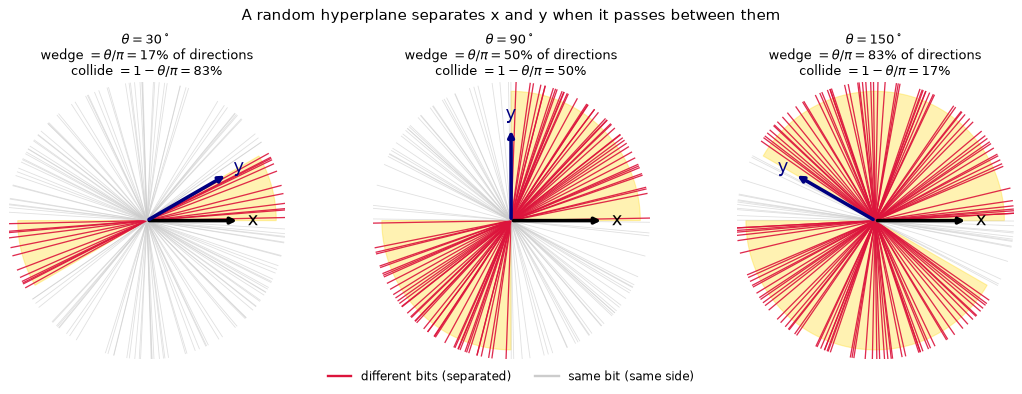

In [2]:
from matplotlib.lines import Line2D

rng = np.random.default_rng(1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), dpi=85)
n_lines = 80
for ax, theta_deg in zip(axes, [30, 90, 150]):
    theta = np.deg2rad(theta_deg)
    x = np.array([1.0, 0.0])
    y = np.array([np.cos(theta), np.sin(theta)])

    # gold wedge between x and y, plus its mirror through the origin
    a = np.linspace(0, theta, 60)
    wedge_x = np.concatenate([[0], 1.4 * np.cos(a), [0]])
    wedge_y = np.concatenate([[0], 1.4 * np.sin(a), [0]])
    ax.fill(wedge_x, wedge_y, color="gold", alpha=0.3, zorder=0)
    ax.fill(-wedge_x, -wedge_y, color="gold", alpha=0.3, zorder=0)

    # random hyperplanes (lines through the origin), coloured by separation
    for beta in rng.uniform(0, np.pi, n_lines):
        direction = np.array([np.cos(beta), np.sin(beta)])
        normal = np.array([-np.sin(beta), np.cos(beta)])
        separates = (x @ normal >= 0) != (y @ normal >= 0)
        seg = np.outer([-1.5, 1.5], direction)
        ax.plot(
            seg[:, 0],
            seg[:, 1],
            color="crimson" if separates else "0.8",
            lw=1.1 if separates else 0.7,
            alpha=0.9 if separates else 0.6,
            zorder=1,
        )

    for vec, name, col in [(x, "x", "black"), (y, "y", "navy")]:
        ax.annotate(
            "",
            xy=vec,
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=col, lw=3),
            zorder=3,
        )
        ax.text(
            1.15 * vec[0],
            1.15 * vec[1],
            name,
            color=col,
            fontsize=15,
            ha="center",
            va="center",
            zorder=3,
        )

    ax.set_title(
        rf"$\theta = {theta_deg}^\circ$"
        + "\n"
        + rf"wedge $= \theta/\pi = ${theta / np.pi:.0%} of directions"
        + "\n"
        + rf"collide $= 1 - \theta/\pi = ${1 - theta / np.pi:.0%}",
        fontsize=11,
    )
    ax.set_aspect("equal")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axis("off")

legend_lines = [
    Line2D([0], [0], color="crimson", lw=2, label="different bits (separated)"),
    Line2D([0], [0], color="0.8", lw=2, label="same bit (same side)"),
]
fig.legend(handles=legend_lines, loc="lower center", ncol=2, frameon=False)
fig.suptitle(
    "A random hyperplane separates x and y when it passes between them",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

Averaging over many random projections confirms the law across the whole range of angles : the measured collision rate traces the $1 - \theta/\pi$ curve.

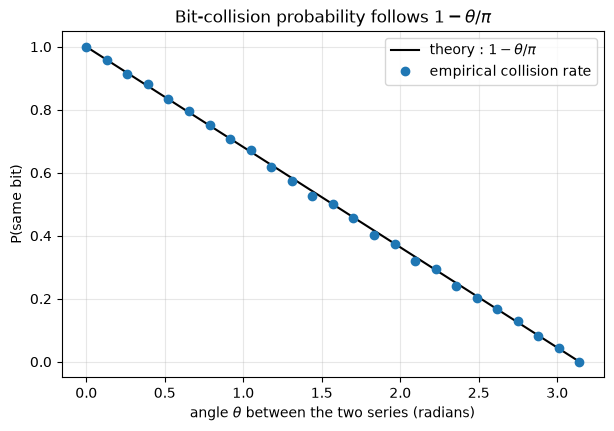

In [3]:
rng = np.random.default_rng(0)

angles = np.linspace(0, np.pi, 25)
n_projections = 5000
empirical = []
for theta in angles:
    # two unit vectors separated by exactly theta
    x = np.array([1.0, 0.0])
    y = np.array([np.cos(theta), np.sin(theta)])
    W = rng.standard_normal((n_projections, 2))
    empirical.append(np.mean(((W @ x) >= 0) == ((W @ y) >= 0)))

theory = 1 - angles / np.pi

plt.figure(figsize=(7, 4.5))
plt.plot(angles, theory, "k-", label=r"theory : $1 - \theta/\pi$")
plt.plot(angles, empirical, "o", color="tab:blue", label="empirical collision rate")
plt.xlabel(r"angle $\theta$ between the two series (radians)")
plt.ylabel("P(same bit)")
plt.title(r"Bit-collision probability follows $1 - \theta/\pi$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Amplification with bits and tables ($k$ and $L$)

A single bit is a very weak hash : even two completely unrelated series ($\theta = \pi/2$) still collide half of the time ($1 - \tfrac{1}{2} = 0.5$). To turn this weak signal into a useful index, SimHash combines many bits using the classic $(k, L)$ amplification scheme (Indyk & Motwani, 1998), controlled by two parameters :

- AND-amplification, controlled by `n_bits_per_table` ($k$). Within one hash *table*, we concatenate $k$ independent bits into a single key. Two series land in the same bucket only if all $k$ bits agree. As the bits are independent, the collision probability of a full key is :
$$ \left(1 - \frac{\theta}{\pi}\right)^k $$
Raising to the power $k$ pushes this probability down, sharply for large angles and only mildly for small ones : buckets become selective, keeping dissimilar series apart.

- OR-amplification, controlled by `n_tables` ($L$). With a single selective table we would miss a close neighbour as soon as just one of its $k$ bits flips. To recover them, we keep $L$ independent tables (each with its own $k$ random projections) and call a series a candidate if it shares the query's bucket in at least one table. A candidate is missed only if it fails in all $L$ tables, so the probability of retrieving it is :
$$ 1 - \left(1 - \left(1 - \frac{\theta}{\pi}\right)^k\right)^L $$

Plotting this retrieval probability against the cosine similarity gives the characteristic S-curve of LSH. Increasing $k$ shifts the curve to the right and makes it steeper (more selective), while increasing $L$ lifts the curve up (higher recall). Tuning the two together lets us place the "step" of the curve around the similarity threshold we care about.

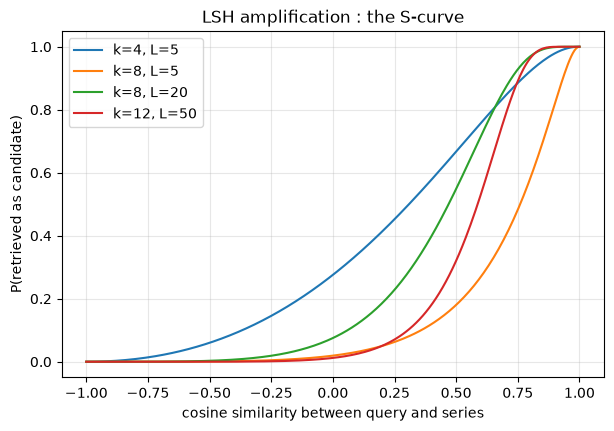

In [4]:
similarity = np.linspace(-1, 1, 300)
theta = np.arccos(np.clip(similarity, -1, 1))
p_one_bit = 1 - theta / np.pi

plt.figure(figsize=(7, 4.5))
for k, L in [(4, 5), (8, 5), (8, 20), (12, 50)]:
    p_key = p_one_bit**k  # AND over k bits within a table
    p_candidate = 1 - (1 - p_key) ** L  # OR over L tables
    plt.plot(similarity, p_candidate, label=f"k={k}, L={L}")

plt.xlabel("cosine similarity between query and series")
plt.ylabel("P(retrieved as candidate)")
plt.title("LSH amplification : the S-curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Building the index : from signatures to buckets

We now look at how aeon turns these ideas into an actual index. We will use a real dataset and the internal helper functions of the module to peek at each step (these are private helpers, used here only to illustrate the mechanics).

In total there are $L \times k$ random projections (`n_tables` $\times$ `n_bits_per_table`). aeon stores them flattened, one vector per projection, in the fitted attribute `hash_funcs_flat_` of shape $(L \cdot k,\ d)$. Hashing the whole collection is then a single matrix product handed to BLAS : stacking the flattened series into a matrix $X_{\text{flat}}$ of shape $(n,\ d)$, the boolean signatures are obtained as $X_{\text{flat}}\, W^\top \geq 0$. This is far faster than looping over series, and is what the `_collection_to_signature` helper does.

In [5]:
from aeon.datasets import load_classification
from aeon.similarity_search.whole_series import SimHashIndexANN
from aeon.similarity_search.whole_series._simhash_index_ann import (
    _collection_to_signature,
    _series_to_signature,
    _signatures_to_keys,
)
from aeon.utils.numba.general import z_normalise_series_2d, z_normalise_series_3d

# a larger, more diverse collection than arrow_head, so that the buckets are
# selective enough for a query to examine clearly fewer than all the series
X, _ = load_classification("ECG5000")
print("collection shape:", X.shape)  # (n_cases, n_channels, n_timepoints)

index = SimHashIndexANN(n_tables=20, n_bits_per_table=26, random_state=0)
index.fit(X)

# fit z-normalizes internally (normalize=True); reproduce it to hash the same data
X_norm = z_normalise_series_3d(X)
# hash_funcs_flat_ has shape (L*k, d): one flattened projection per row
print("random projections (hash_funcs_flat_):", index.hash_funcs_flat_.shape)

signatures = _collection_to_signature(X_norm, index.hash_funcs_flat_)
print("boolean signatures:", signatures.shape, signatures.dtype)  # (n_cases, L*k)
k_bits = index.n_bits_per_table
key_bits = signatures[0, :k_bits].astype(int)
print(f"the {k_bits} bits forming series 0's key in table 0:", key_bits)

collection shape: (5000, 1, 140)


random projections (hash_funcs_flat_): (520, 140)
boolean signatures: (5000, 520) bool
the 26 bits forming series 0's key in table 0: [0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 1 0 1 1 0 0 0]


### From bits to bucket keys

Each table maps a series to *one* bucket, but a table's key is made of $k$ separate bits. We pack these $k$ booleans into a single integer in $[0, 2^k)$ by reading them as the binary digits of that integer : bit $j$ contributes $2^j$ when it is set. The `_signatures_to_keys` helper does this with a vectorized dot product over the powers of two, which replaces the slow per-series byte conversions that used to be the bottleneck of index construction.

Each of the $L$ tables is then just a Python dictionary mapping a bucket key to the list of series indices that fall in it ; this is the fitted attribute `tables_`. Filling these dictionaries (one insertion per series in every table) is what now dominates the build on large collections.

In [6]:
keys = _signatures_to_keys(signatures, index.n_tables, index.n_bits_per_table)
print("bucket keys:", keys.shape)  # (n_cases, n_tables): one integer key per table
print("series 0 keys in the first 5 tables:", keys[0, :5])

# tables_ maps each bucket key to the list of series that fall in it
key_of_series0_table0 = int(keys[0, 0])
bucket = index.tables_[0][key_of_series0_table0]
print(f"\ntable 0 holds {len(index.tables_[0])} distinct buckets")
print(
    f"series 0 shares bucket {key_of_series0_table0} (table 0) "
    f"with {len(bucket)} series (including series 0 itself)"
)
print("first members of that bucket:", bucket[:12])

bucket keys: (5000, 20)
series 0 keys in the first 5 tables: [ 7131814 47035100 11581721 20559114 57340433]

table 0 holds 1185 distinct buckets
series 0 shares bucket 7131814 (table 0) with 179 series (including series 0 itself)
first members of that bucket: [  0   2  37  59  61  89 149 184 197 199 224 231]


## Answering a query

To answer a query, the index :

1. hashes the query into its $L \times k$ bits and packs them into one bucket key per table (exactly as during fit) ;
2. looks up the query's bucket in each of the $L$ tables and gathers the union of the series found there, the candidates ;
3. ranks each candidate by its collision count, the number of tables in which it shares the query's bucket. A closer series agrees on more bits, so it tends to collide in more tables : the collision count is a cheap proxy for similarity, used in place of any exact distance computation ;
4. returns the top $K$ candidates (the `k` passed to `predict(..., k=K)`, distinct from the per-table bit count $k$ of the amplification section), reporting the proxy distance $1 / \texttt{collision\_count}$ (smaller means more collisions, i.e. closer).

Because we only ever touch the series that share a bucket with the query, and never compute an exact distance, queries are fast : the candidates are gathered and their collisions tallied only over the bucket hits, so the query cost scales with the number of candidates rather than with the whole collection. This makes a query much cheaper than a linear scan of exact distances whenever the buckets are selective. The flip side is that the result is approximate : a true neighbour that never lands in the query's bucket in any table is missed, and ties in the collision count are broken arbitrarily (by index). This is the accuracy-versus-speed trade-off explored experimentally in the [speedups notebook](code_speed.ipynb).

The cell below runs a query both exactly (`NaiveSeriesSearch`) and approximately (`SimHashIndexANN`). To compare like with like, we use `NaiveSeriesSearch(normalize=True)` as the exact reference : the index is fit with its default `normalize=True`, so both rank z-normalized series, and for z-normalized series the squared-Euclidean distance is $d^2 = 2m\,(1 - r)$ (with $r$ the Pearson correlation, i.e. the cosine similarity of the centered series), so the exact squared-Euclidean ranking and the angular / cosine ranking the index targets are the same. Here the index examines only a subset of the collection, yet still recovers the exact nearest neighbour, and the rest of its top-$K$ overlaps with, but does not perfectly match, the exact result. How large that subset is (and hence how large the speed-up) depends on $k$ and $L$ ; for fixed $k$ and $L$ the fraction of the collection examined stays roughly constant as the collection grows, so the advantage over the brute-force scan is largest on large collections (see the [speedups notebook](code_speed.ipynb)).

In [7]:
from aeon.similarity_search.whole_series import NaiveSeriesSearch

query = X[0]  # use one series of the collection as the query
K = 5  # neighbours to return (the k in predict(..., k=K)), not n_bits_per_table

# exact search: compares the query against all n_cases series, using the same
# normalization as the index (normalize=True) so both rank z-normalized series
exact_idx, exact_dist = NaiveSeriesSearch(normalize=True).fit(X).predict(query, k=K)

# approximate search with the index
approx_idx, approx_dist = index.predict(query, k=K)

# reproduce the candidate gathering to see how few series were examined
q_norm = z_normalise_series_2d(query)
q_sig = _series_to_signature(q_norm, index.hash_funcs_flat_)
q_keys = _signatures_to_keys(q_sig[None, :], index.n_tables, index.n_bits_per_table)[0]
candidates = set()
for t in range(index.n_tables):
    bucket = index.tables_[t].get(int(q_keys[t]))
    if bucket is not None:
        candidates.update(bucket)

print(f"candidates examined : {len(candidates)} out of {X.shape[0]} series")
print("exact neighbours       :", exact_idx)
print("approximate neighbours :", approx_idx)
print("proxy distances (1 / collision count):", np.round(approx_dist, 4))

candidates examined : 1046 out of 5000 series
exact neighbours       : [   0 2910 2007 1255   64]
approximate neighbours : [   0 2910   94  893 2007]
proxy distances (1 / collision count): [0.05   0.1429 0.2    0.2    0.2   ]


## The choice of random projection distribution

The derivation of the $1 - \theta/\pi$ collision probability assumes the random normal $w$ has a rotationally symmetric (isotropic) distribution, so that its direction is uniform. The standard Gaussian has exactly this property, which is why `hash_func_distribution="gaussian"` is the default and the only choice for which the collision probability is exact.

aeon also offers `"discrete"` (drawing each $w_j$ from $\{-1, +1\}$) and `"uniform"` (drawing from $[-1, 1]$). These are not rotationally symmetric, but because each projection $\langle w, x \rangle$ is a sum of many independent terms, the pair of projections of two series is jointly close to Gaussian by the central limit theorem (and the collision probability depends only on that joint law), so these variants approximate the same $1 - \theta/\pi$ behaviour. `"gaussian"` remains the recommended default.

## Conclusion

We saw that SimHash hashes a series by the sign of random projections, that a single bit collides with probability $1 - \theta/\pi$ (so collisions track the angular / cosine similarity), and that concatenating $k$ bits per table over $L$ tables amplifies this into a tunable S-curve. aeon turns this into an index by hashing the whole collection with a single BLAS matrix product, packing each table's bits into an integer bucket key, and storing buckets as dictionaries ; a query then only probes its buckets and ranks the few candidates by their collision count.

To go further :

- [Time Series Similarity Search with aeon](similarity_search.ipynb), an overview of the module and its estimators.
- [Deep dive in the distance profiles](distance_profiles.ipynb), the theory behind the exact, subsequence-based methods.
- [Analysis of the speedups](code_speed.ipynb), how to tune `n_tables` and `n_bits_per_table` for recall versus query speed, and the float32 / float64 trade-off.

### References

- M. S. Charikar. "Similarity estimation techniques from rounding algorithms". STOC 2002. (Introduces SimHash / sign random projections as an LSH family for cosine similarity.)
- P. Indyk and R. Motwani. "Approximate nearest neighbors: towards removing the curse of dimensionality". STOC 1998. (The multi-table $(k, L)$ LSH scheme.)